# Frequency reconstruction and spectral recovery, Pagani *et al.* figures

**PATCHALIAS.** This notebook produces **two kinds of figure and nothing else**, on the
pure-sinusoid sweep of Deliverable~1's Data section:

1. **Reconstruction**, input frequency against the dominant frequency the model actually generates,
   with the ideal diagonal. Where the curve leaves the diagonal, the model is rebuilding the wrong
   frequency.
2. **Spectral recovery map**, a red-to-green strip along the spectrum saying where the frequency is
   still readable from the model's representation and where it is not. Pagani *et al.* read this in
   three states; here the scale between them is **continuous**, so a band that degrades gradually
   reads as a gradient rather than as a staircase. The old thresholds survive as the colour
   anchors: $0.5$ is chance, $0.6$ still carries the "lost" red and $0.9$ the "recovered" green.

Every figure is written to disk, one file per figure: the pair per geometry, each panel of that
pair on its own so either can be used as a standalone figure, and the two cross-geometry summaries.
The final cell prints the manifest of what was written.

It is deliberately separate from `bayesian_analysis.ipynb` and self-contained: every figure is
built here from `probe_lib`, so nothing depends on the older notebooks in `chronos/testing/`.
Signals are **pure sinusoids** ($2$–$250$ Hz), which is the first analysis of Deliverable~1; the
generator backgrounds belong to the Bayesian part.

Outputs go next to the Bayesian run, in `_run/<mode>/pagani/`.


## 0, Setup

In [1]:
import importlib.util, subprocess, sys

REQUIRED = {"torch": "torch", "chronos": "chronos-forecasting",
            "sklearn": "scikit-learn", "pyarrow": "pyarrow"}
missing = [pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("nothing to install")

nothing to install


In [2]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/FedericoSabbadini/patchAliasing.git"
BRANCH   = "main"
IN_COLAB = "google.colab" in sys.modules
MARKER   = Path("chronos") / "bayesian" / "probe_lib.py"
REFRESH  = True      # pull before running; see the note below before setting this to False

def _git(*a, cwd=None):
    return subprocess.run(("git",) + a, cwd=cwd, check=True,
                          capture_output=True, text=True).stdout.strip()

def find_repo() -> Path:
    """Locate a working copy, or put one in place, and make sure it is not stale.

    The stale case is the one that costs a run. A Colab runtime keeps /content between executions,
    so a checkout made earlier in the session is still there; the previous version of this cell
    cloned only when the directory was absent, so it silently reused that old checkout and a fix
    pushed in the meantime never arrived. The symptom is subtle: everything runs, and only the
    design banner is wrong. REFRESH forces the checkout to match the remote before anything is
    imported.
    """
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / MARKER).exists():
            return cand                      # a real working copy: leave it alone, do not reset it
    target = Path("/content/patchAliasing") if IN_COLAB else here / "patchAliasing"
    if (target / ".git").exists():
        if REFRESH:
            _git("fetch", "--depth", "1", "origin", BRANCH, cwd=str(target))
            _git("reset", "--hard", f"origin/{BRANCH}", cwd=str(target))
            _git("clean", "-fd", "--", "chronos", cwd=str(target))
    else:
        _git("clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(target))
    if not (target / MARKER).exists():
        raise FileNotFoundError(f"{MARKER} missing from {target}; push it or upload it by hand.")
    return target

REPO = find_repo()
sys.path.insert(0, str(REPO / "chronos" / "bayesian"))

# A kernel that already imported probe_lib keeps the OLD module object even after the pull above,
# because import is a no-op for an already-loaded name. Evicting it here is what makes "restart the
# runtime" unnecessary.
for _m in ("probe_lib", "testing_lib"):
    sys.modules.pop(_m, None)

print("repository:", REPO)
try:
    print("commit:    ", _git("log", "-1", "--format=%h %ad  %s", "--date=short", cwd=str(REPO)))
except Exception as e:
    print("commit:     unknown -", e)


repository: C:\Users\feder\Desktop\patchAliasing
commit:     d6ce492 2026-08-17  Refactor deliverable tables and update descriptions


In [3]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold

warnings.filterwarnings("ignore")
import probe_lib as pl

SEED = pl.SEED
np.random.seed(SEED)

# ---- what to run ----------------------------------------------------------------------
# Every geometry of the published sweep. All are retrained checkpoints under the same budget;
# amazon/chronos-bolt-tiny is not part of the design. Set GEOMETRIES = [(16, 16)] to look at one.
GEOMETRIES = pl.MODELS  # all geometries incl. p32-s28: recon context (512//S)*S=504 is divisible by 28, no padding

SMOKE = False                      # True -> coarse grid, ~1 minute, for a pipeline check

# ---- Pagani parity --------------------------------------------------------------------
# These four numbers are the ones that make this notebook a reproduction of Pagani et al.
# rather than a second, slightly different experiment, and each of them matters:
#
#   context   ~512 samples snapped DOWN to a whole number of strides, exactly as
#             chronos/testing/chronosBolt_layer_probing.ipynb. With fs = 512 a context of 512
#             samples holds an integer number of cycles at EVERY integer frequency, so the input
#             is exactly periodic and carries no spectral leakage. probe_lib's CTX = 480 is a
#             different choice, made so the patch grid closes for the H1/H2/H3 collection; at 480
#             only multiples of 16 Hz are leakage-free, which is not the setup the paper measures.
#   GEN_LEN   512 -> the rollout DFT has 1 Hz bins. At 256 the bins are 2 Hz wide and the
#             reconstruction curve is quantised to twice the step, which is visible as a coarser
#             staircase and inflates the RMSE floor from ~0.29 to ~0.58 Hz.
#   N_PHASE   10 phases per frequency for the probe, 4 for the rollout, as in the paper.
FREQ_STEP   = 8 if SMOKE else 1    # sweep step [Hz]; 1 Hz is the grid Deliverable 1 specifies
N_PHASE     = 3 if SMOKE else 10   # phases per frequency (probing dataset)
GEN_LEN     = 128 if SMOKE else 512   # autoregressive rollout length
N_PHASE_GEN = 2 if SMOKE else 4    # phases per frequency (rollout)
BATCH       = 64

def pagani_context(S: int) -> int:
    """~512 samples, snapped down to a whole number of strides."""
    return (512 // S) * S

# ---- output directory: its own, and emptied before the run ----------------------------
# This notebook writes next to the Bayesian run but NOT into it: _run/<mode>/pagani/ is used by
# nothing else, so a stale 5-model run can never be read as part of a fresh 19-model one.
CLEAN_OUTPUT = True       # False -> keep whatever is there and overwrite file by file
ARCHIVE_OLD  = True       # True -> move the previous run aside instead of deleting it

import shutil
_root = REPO / "chronos" / "bayesian" / "_run"
OUT = _root / ("smoke" if SMOKE else "full") / "pagani"

if CLEAN_OUTPUT and OUT.exists() and any(OUT.iterdir()):
    if ARCHIVE_OLD:
        n = 1
        while (dest := OUT.with_name(f"pagani_prev{n:02d}")).exists():
            n += 1
        shutil.move(str(OUT), str(dest))
        print(f"previous run archived -> {dest}")
    else:
        shutil.rmtree(OUT)
        print(f"previous run deleted  -> {OUT}")
OUT.mkdir(parents=True, exist_ok=True)
assert not any(OUT.iterdir()), f"{OUT} is not empty; nothing was run"

FREQS = np.arange(pl.BAND[0], pl.BAND[1] + 1e-9, FREQ_STEP)
print(f"{'SMOKE' if SMOKE else 'FULL'} | {len(GEOMETRIES)} geometries | "
      f"{len(FREQS)} frequencies x up to {N_PHASE} phases | rollout {GEN_LEN} samples")
print(f"contexts: {{S: (512//S)*S}} = {{{', '.join(f'{S}: {pagani_context(S)}' for S in sorted({s for _, s in GEOMETRIES}))}}}")
print(f"figures and tables -> {OUT}")


previous run archived -> C:\Users\feder\Desktop\patchAliasing\chronos\bayesian\_run\full\pagani_prev01
FULL | 22 geometries | 249 frequencies x up to 10 phases | rollout 512 samples
contexts: {S: (512//S)*S} = {4: 512, 5: 510, 8: 512, 12: 504, 15: 510, 16: 512, 20: 500, 24: 504, 28: 504, 32: 512}
figures and tables -> C:\Users\feder\Desktop\patchAliasing\chronos\bayesian\_run\full\pagani


## 1, Measurement

Two quantities per geometry, both on pure sinusoids.

**Reconstruction.** The model is given a sinusoid, its median forecast is fed back into the context,
and the rollout continues to `GEN_LEN` samples. The **dominant** frequency of the output is read off
as `argmax |DFT|` and compared with the frequency that went in. On the diagonal the tone survives;
a flat segment means a range of inputs collapses onto one output, and a jump means the model
rebuilds a tone that was never there.

**Spectral recovery.** A linear probe is trained on the $256$-d $[\mathrm{REG}]$ vector at the
projected head, where the paper localises the compression drop, and its cross-validated accuracy
is mapped along the spectrum. This asks something more basic than the rollout: is the frequency
still *present* in the representation, whatever the forecast then does with it?

Two probing tasks are computed. The **seven band tasks** are the paper's, each asking whether a tone
falls in the lower or upper half of its band; they carry a known artefact, since a task is genuinely
ambiguous *at its own decision boundary*, which is why the project's earlier testing notebook
dropped this figure. The **local discrimination** task has no such artefact: at each frequency it
asks one question of constant difficulty, can the probe separate $f-\Delta$ from $f+\Delta$?, so
every column is comparable. That is the row to trust, and the one used for the cross-model
comparison.

In [4]:
STAGE = "output_head"          # the paper's h4: the projected quantile head
DELTA_BINS = 1                 # local task compares neighbours, so delta = DELTA_BINS * FREQ_STEP


def probe_accuracy(X, y, groups=None, seed=SEED):
    """Cross-validated per-example correctness of a linear probe.

    `groups` is what separates the two tasks below, and it is not a detail.

    Band tasks: the classes are two HALVES OF A BAND, each containing many frequencies, so a probe
    that memorises individual frequencies can score well without ever learning the band boundary.
    Folds are therefore grouped by frequency (StratifiedGroupKFold): every phase of a held-out
    frequency is excluded from training, and the probe has to generalise the boundary. This is what
    chronos/testing/chronosBolt_layer_probing.ipynb does for its Fig. 4; an ungrouped split
    inflates these rows.

    Local task: the two classes ARE two frequencies, f-delta and f+delta, so grouping by frequency
    would put each class entirely in one fold and is impossible. A plain stratified split is the
    correct one here: it holds out phases, which is exactly the generalisation being asked about.
    """
    from sklearn.model_selection import StratifiedGroupKFold
    if len(np.unique(y)) < 2:
        return None
    if groups is None:
        n_splits = int(min(5, np.bincount(y).min()))
        cv = StratifiedKFold(n_splits, shuffle=True, random_state=seed) if n_splits >= 2 else None
    else:
        n0 = len(np.unique(groups[y == 0])); n1 = len(np.unique(groups[y == 1]))
        n_splits = int(min(5, n0, n1))
        cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True,
                                  random_state=seed) if n_splits >= 2 else None
    if cv is None:
        return None
    train_min = len(y) - int(np.ceil(len(y) / n_splits))
    n_comp = max(2, min(20, X.shape[1], train_min - 1))
    clf = make_pipeline(StandardScaler(), PCA(n_components=n_comp),
                        LogisticRegression(max_iter=2000))
    yhat = cross_val_predict(clf, X, y, cv=cv, groups=groups)
    return (yhat == y).astype(float)


def rollout_dominant(probe, freqs, n_phase, ctx_len):
    """Dominant output frequency after an autoregressive rollout, averaged over phases.

    All (frequency, phase) pairs advance in lockstep, so each rollout step is one batched forward
    pass rather than one per signal.
    """
    items = [(f, ph) for f in freqs for ph in pl.phases_Sf(f, n_phase)]
    ctx = np.stack([pl.build_context(None, f, ph, ctx_len) for f, ph in items])   # pure sinusoids
    gen = np.zeros((len(items), 0), dtype=np.float32)
    while gen.shape[1] < GEN_LEN:
        step = probe.forecast(ctx)
        gen = np.concatenate([gen, step], axis=1)
        ctx = np.concatenate([ctx, step], axis=1)[:, -ctx_len:]                   # slide the window
    gen = gen[:, :GEN_LEN]
    x = gen - gen.mean(axis=1, keepdims=True)          # remove DC before reading the peak
    mag = np.abs(np.fft.rfft(x, axis=1))
    fr = np.fft.rfftfreq(GEN_LEN, d=1 / pl.FS)
    dom = fr[np.argmax(mag[:, 1:], axis=1) + 1]        # and skip the DC bin outright
    out = pd.DataFrame(items, columns=["freq", "phase"])
    out["dominant"] = dom
    return out.groupby("freq")["dominant"].agg(["mean", "std"]).reset_index()


def spectral_accuracy(probe, freqs, n_phase, ctx_len):
    """Per-frequency probe accuracy: the seven band tasks, plus the local f+/-delta task."""
    items = [(f, ph) for f in freqs for ph in pl.phases_Sf(f, n_phase)]
    ctx = np.stack([pl.build_context(None, f, ph, ctx_len) for f, ph in items])
    feats = probe.capture_reg(ctx)[STAGE]
    lab_f = np.array([f for f, _ in items])

    rows, labels = [], []
    for (name, lo, hi, bnd) in pl.BAND_TASKS:
        m = (lab_f >= lo) & (lab_f <= hi)
        fm = lab_f[m]
        ok = probe_accuracy(feats[m], (fm > bnd).astype(int), groups=fm)   # grouped by frequency
        a = np.full(len(freqs), np.nan)
        if ok is not None:
            for ci, f in enumerate(freqs):
                sel = fm == f
                if sel.any():
                    a[ci] = ok[sel].mean()
        rows.append(a); labels.append(f"band task {name}")

    local = np.full(len(freqs), np.nan)
    for ci in range(DELTA_BINS, len(freqs) - DELTA_BINS):
        m = np.isin(lab_f, [freqs[ci - DELTA_BINS], freqs[ci + DELTA_BINS]])
        ok = probe_accuracy(feats[m], (lab_f[m] == freqs[ci + DELTA_BINS]).astype(int))
        if ok is not None:
            local[ci] = ok.mean()
    rows.append(local); labels.append(f"local $f\\pm{DELTA_BINS * FREQ_STEP:g}$ Hz")
    return np.vstack(rows), labels


In [5]:
# One geometry at a time: load, measure, free. Chronos-Bolt-tiny is small, but Colab runtimes are
# not, and holding nineteen pipelines at once buys nothing here.
RESULTS = {}
for (P, S) in GEOMETRIES:
    ctx_len = pagani_context(S)
    probe = pl.Probe(P, S, device="cpu", batch_size=BATCH)
    print(f"\n=== {probe.label}  (P={probe.P}, S={probe.S}, context={ctx_len}) ===", flush=True)
    try:
        recon = rollout_dominant(probe, FREQS, N_PHASE_GEN, ctx_len)
        acc, row_labels = spectral_accuracy(probe, FREQS, N_PHASE, ctx_len)
        RESULTS[probe.tag] = dict(P=probe.P, S=probe.S, label=probe.label, ctx=ctx_len,
                                  recon=recon, acc=acc, row_labels=row_labels)
        rmse = float(np.sqrt(np.mean((recon["mean"] - recon["freq"]) ** 2)))
        good = np.nanmean(acc[-1] >= 0.9) * 100
        print(f"    spectral RMSE {rmse:6.1f} Hz | local task: {good:.0f}% of the band recovered")
    finally:
        probe.close()

# archive the numbers next to the figures, in this notebook's own directory
for tag, r in RESULTS.items():
    r["recon"].to_parquet(OUT / f"recon_{tag}.parquet", index=False)
    pd.DataFrame(r["acc"].T, columns=r["row_labels"], index=FREQS).rename_axis("freq_hz") \
      .to_parquet(OUT / f"spectral_accuracy_{tag}.parquet")
print(f"\nmeasured {len(RESULTS)} geometries")


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 12615.01it/s]


=== p8-s4 (local p8-s4-seed42)  (P=8, S=4, context=512) ===


    spectral RMSE  137.3 Hz | local task: 91% of the band recovered


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

...

    spectral RMSE  139.9 Hz | local task: 84% of the band recovered


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 11222.44it/s]


=== p32-s32 (local p32-s32-seed42)  (P=32, S=32, context=512) ===


    spectral RMSE  125.4 Hz | local task: 66% of the band recovered

measured 22 geometries


## 2, Per-geometry figures

Three files per geometry: the two panels side by side, and then each panel again on its own, so a
single panel can go into the deliverable without cropping the pair.


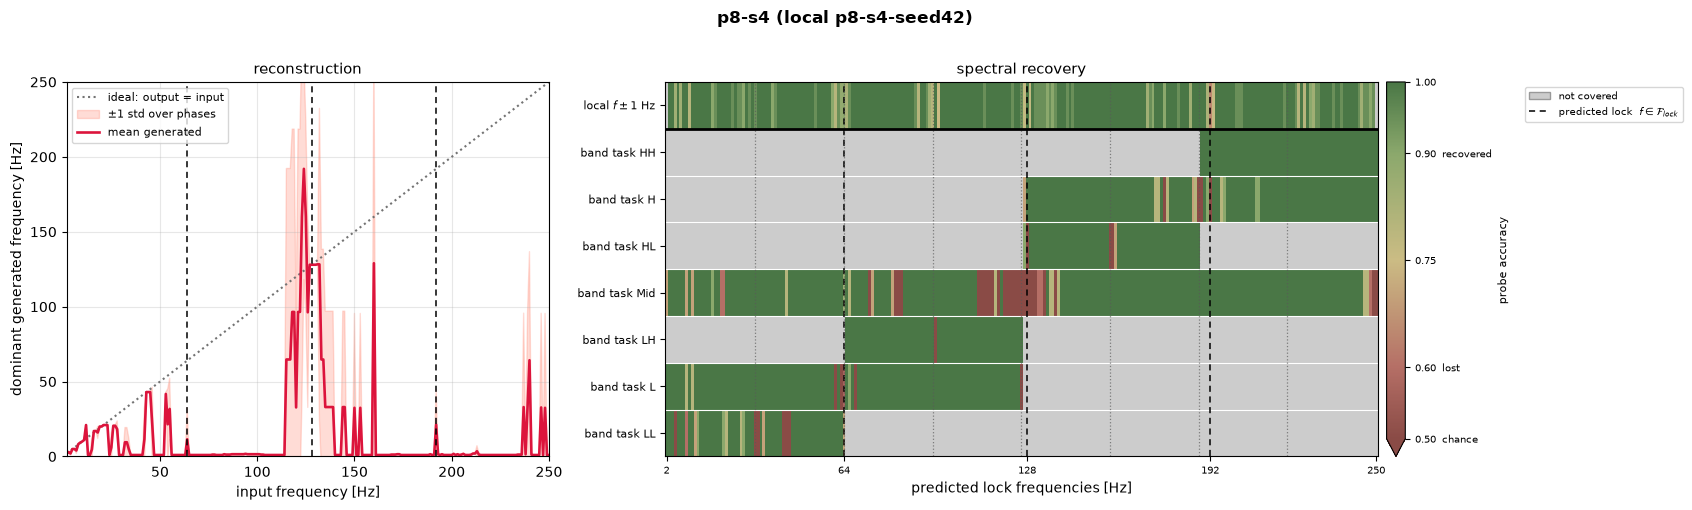

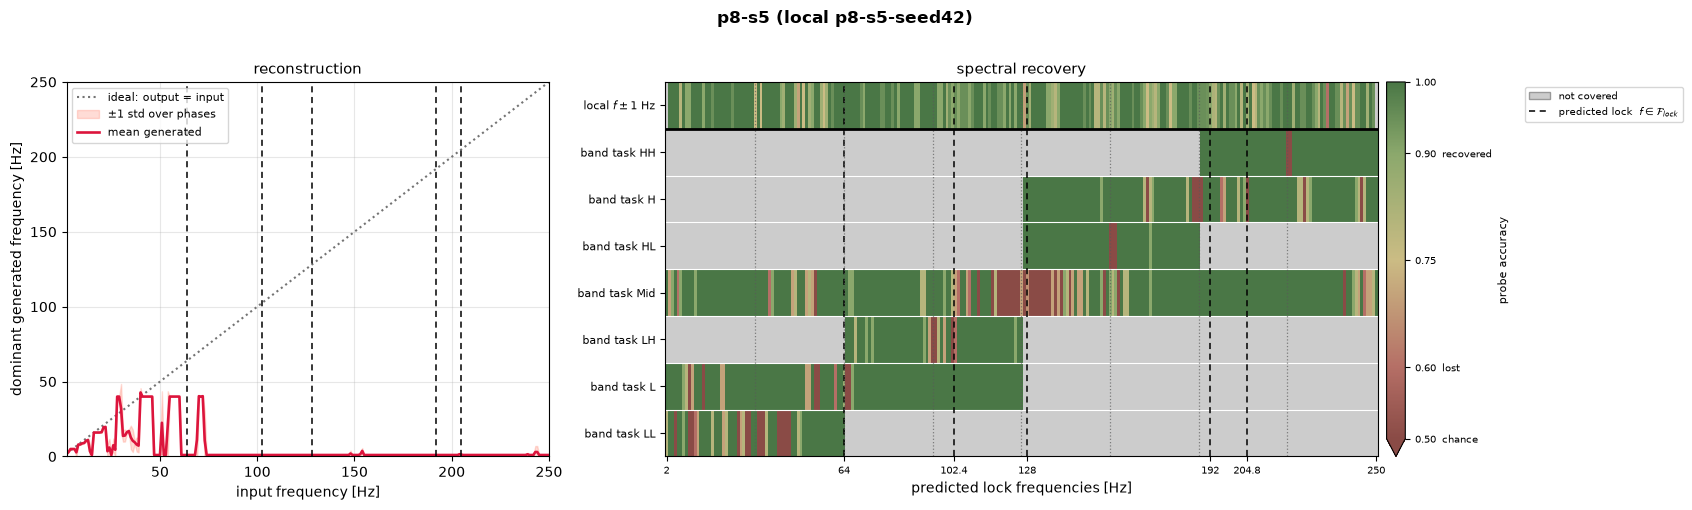

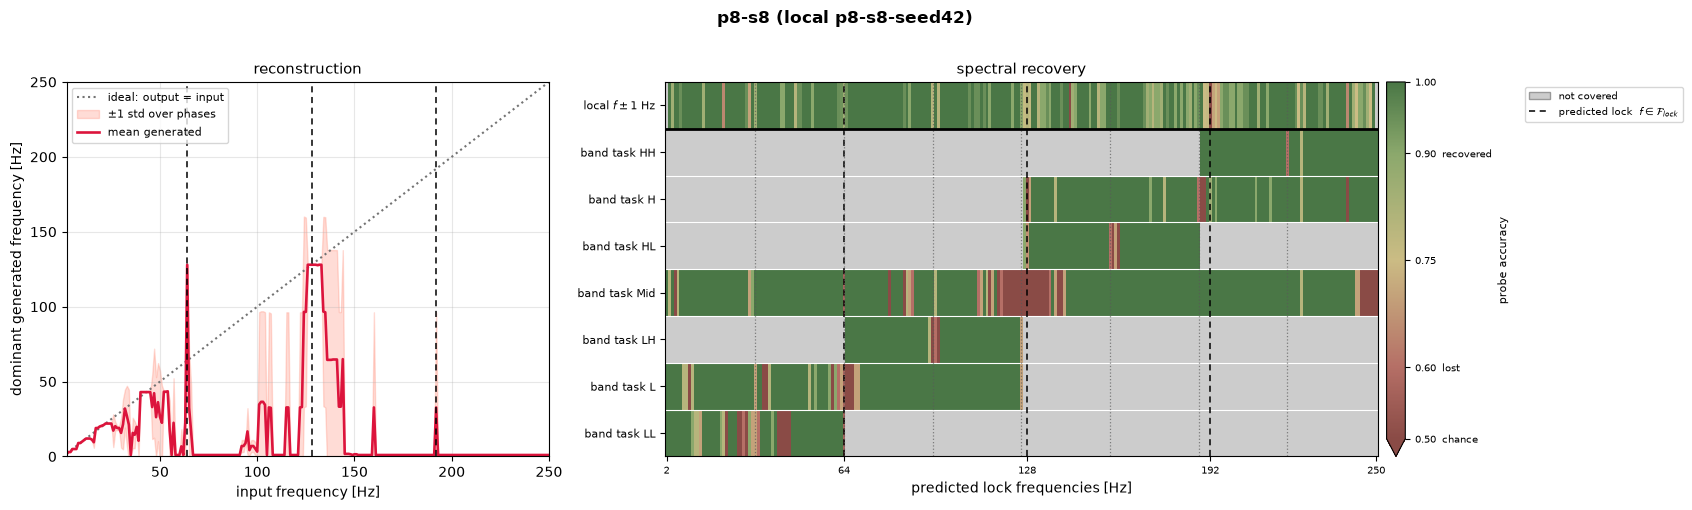

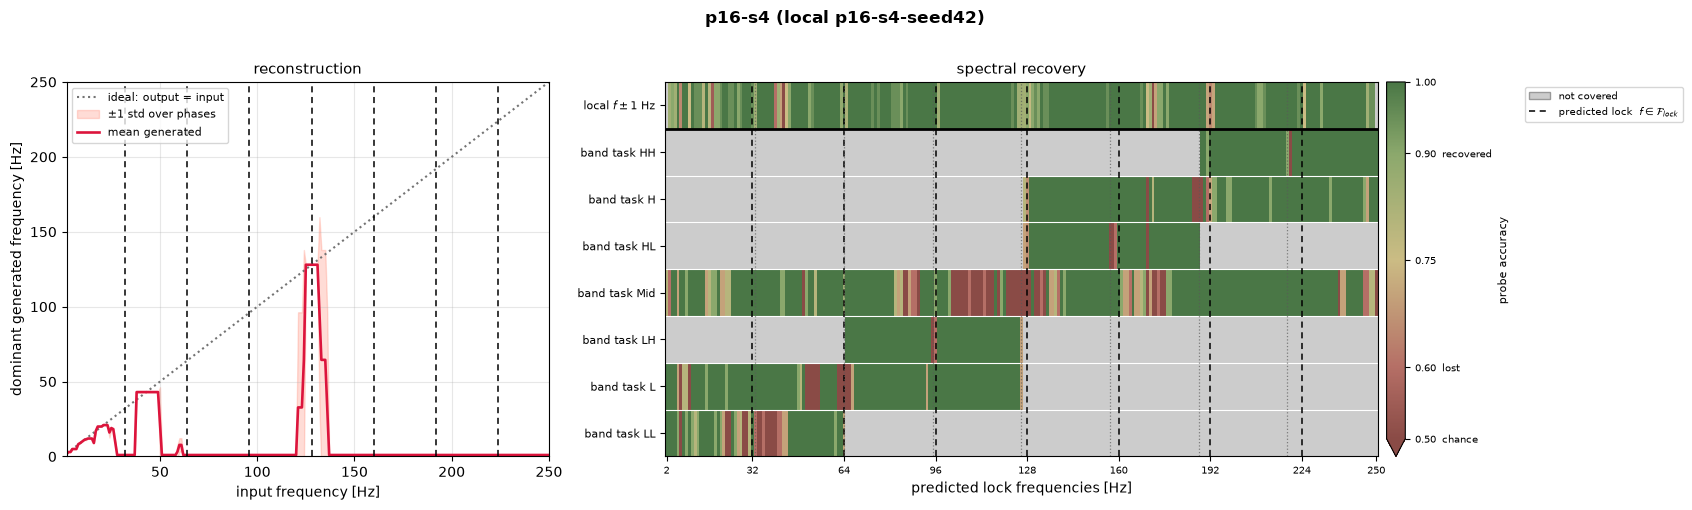

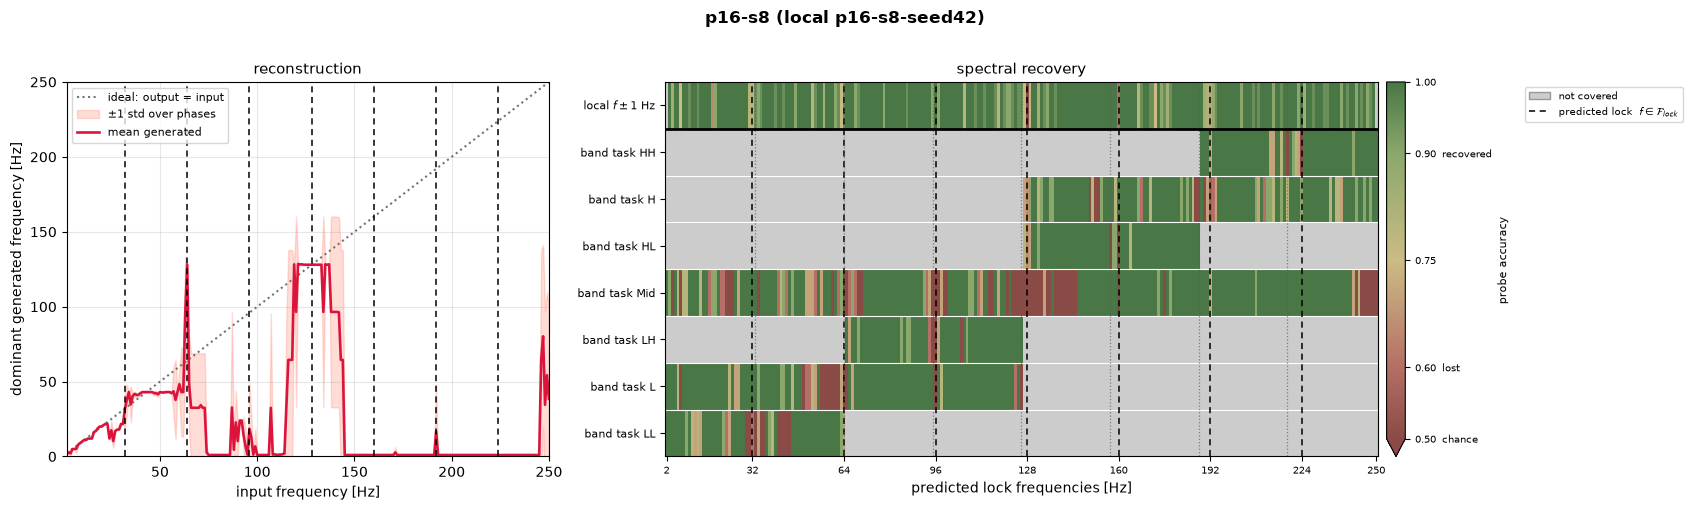

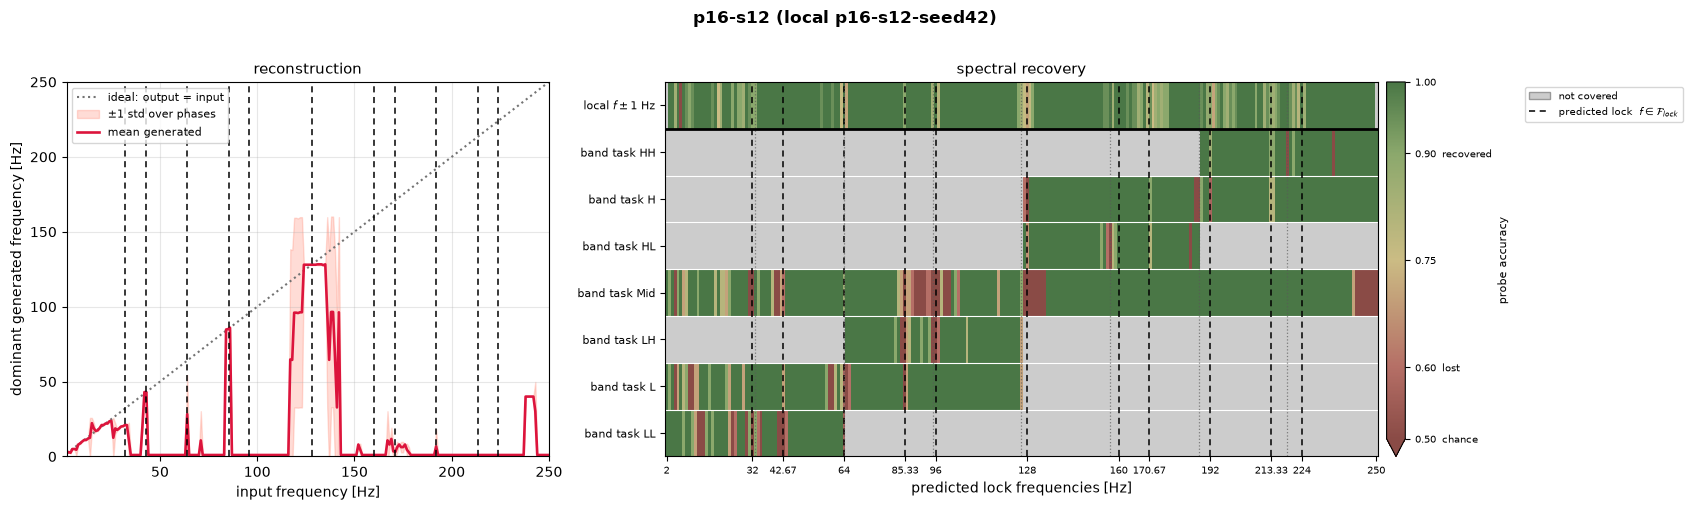

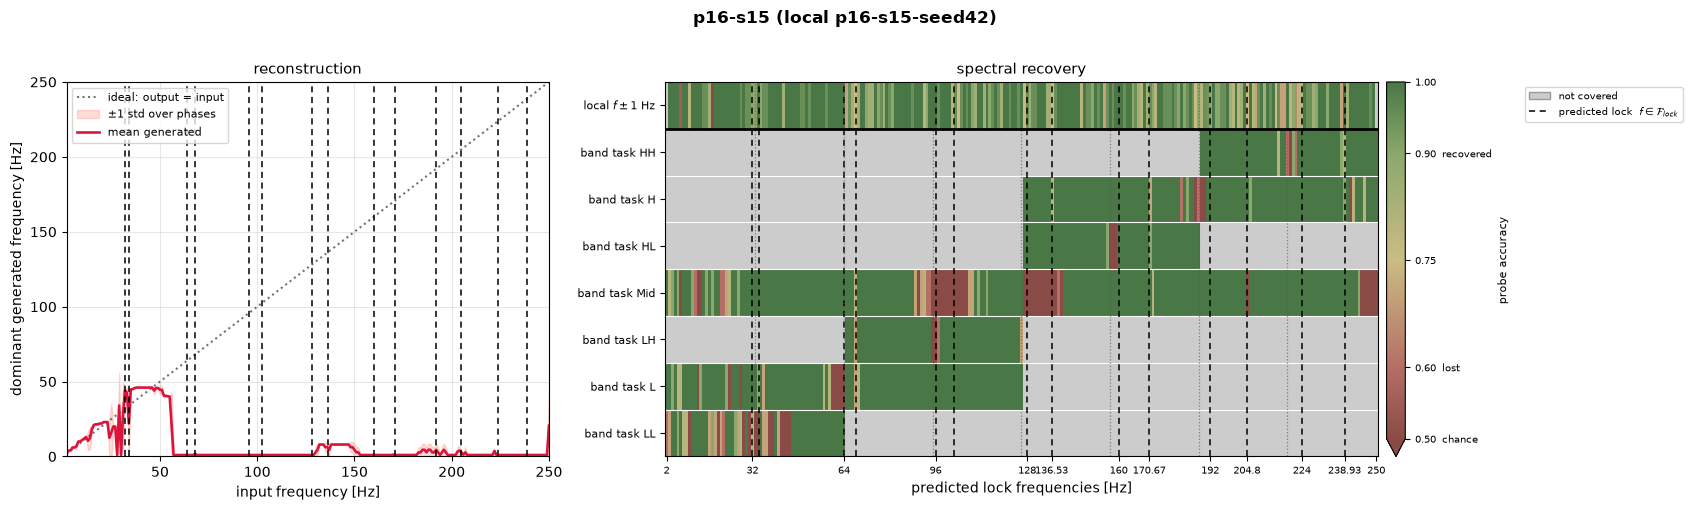

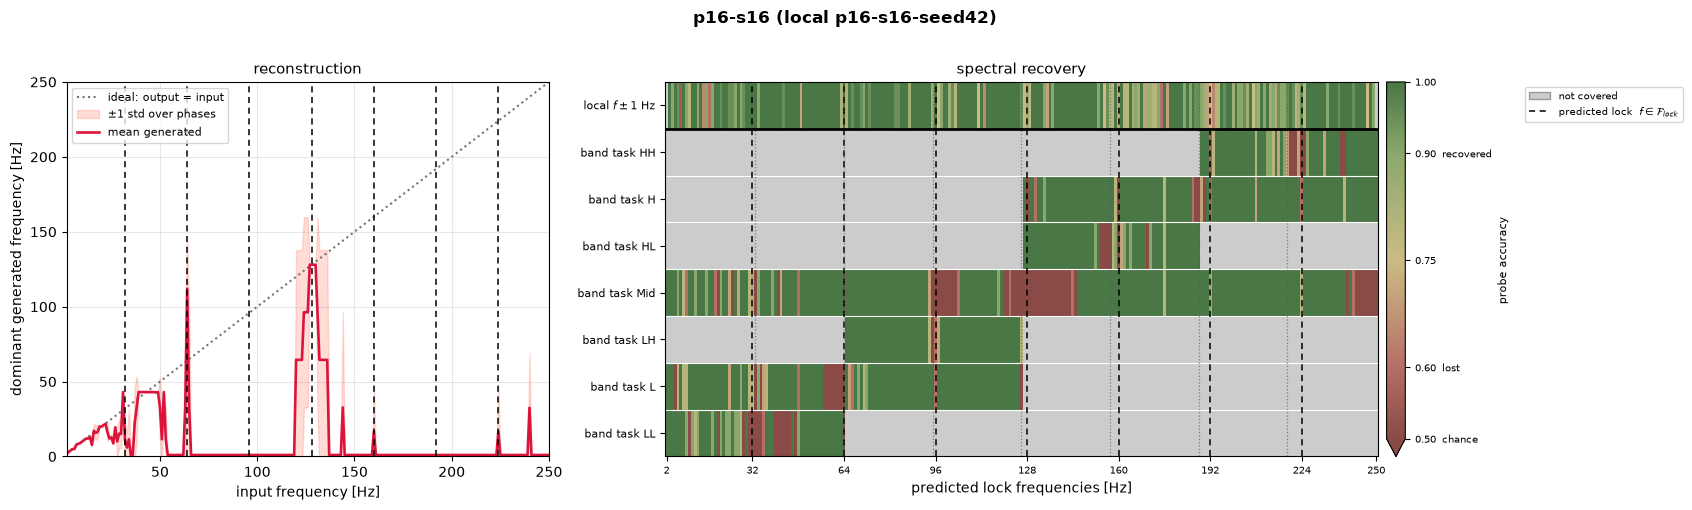

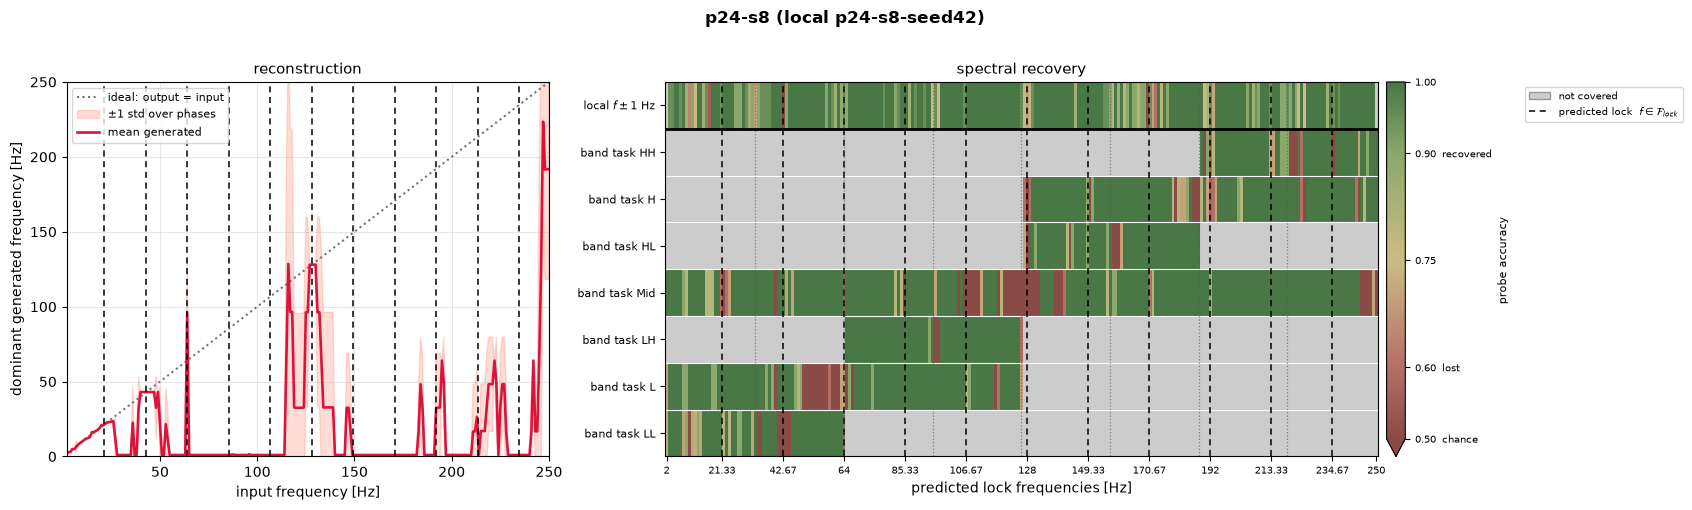

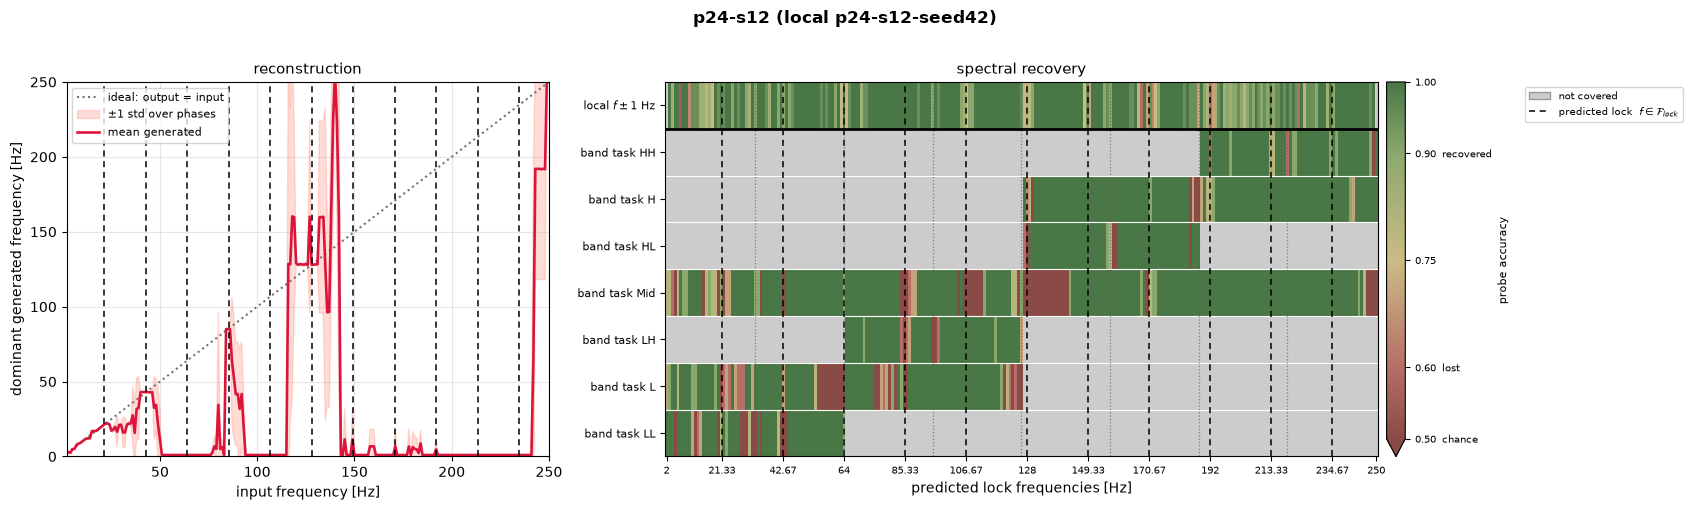

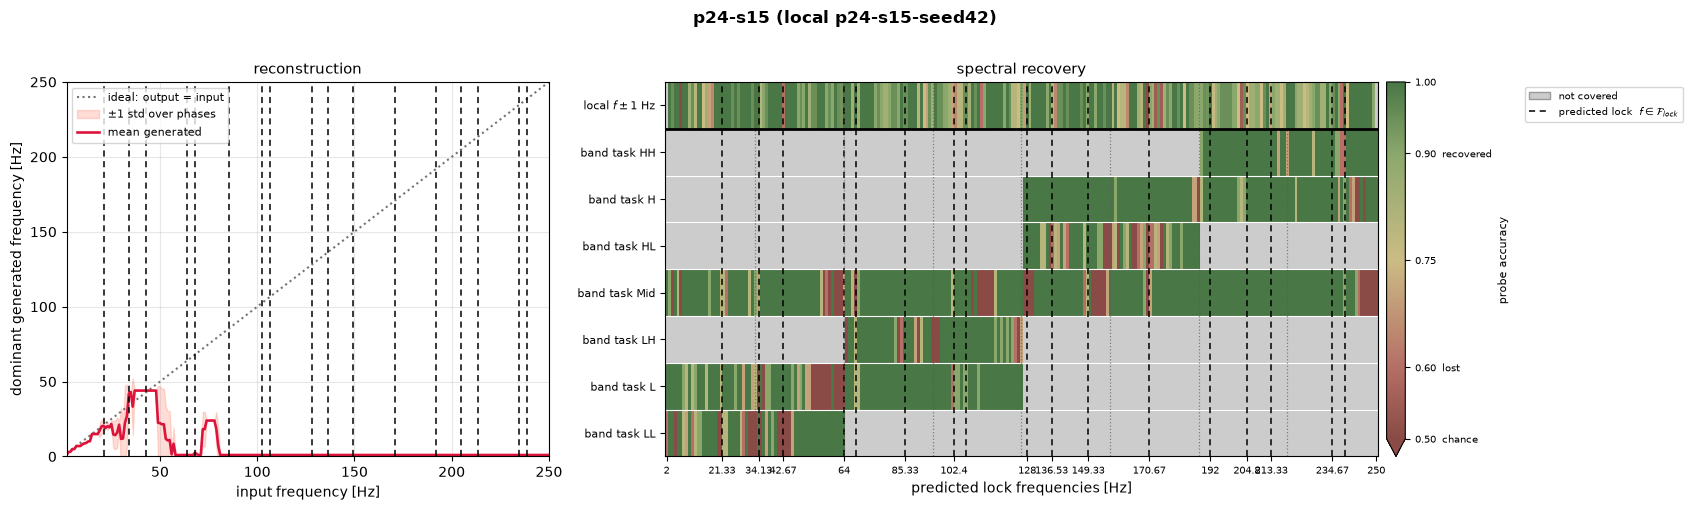

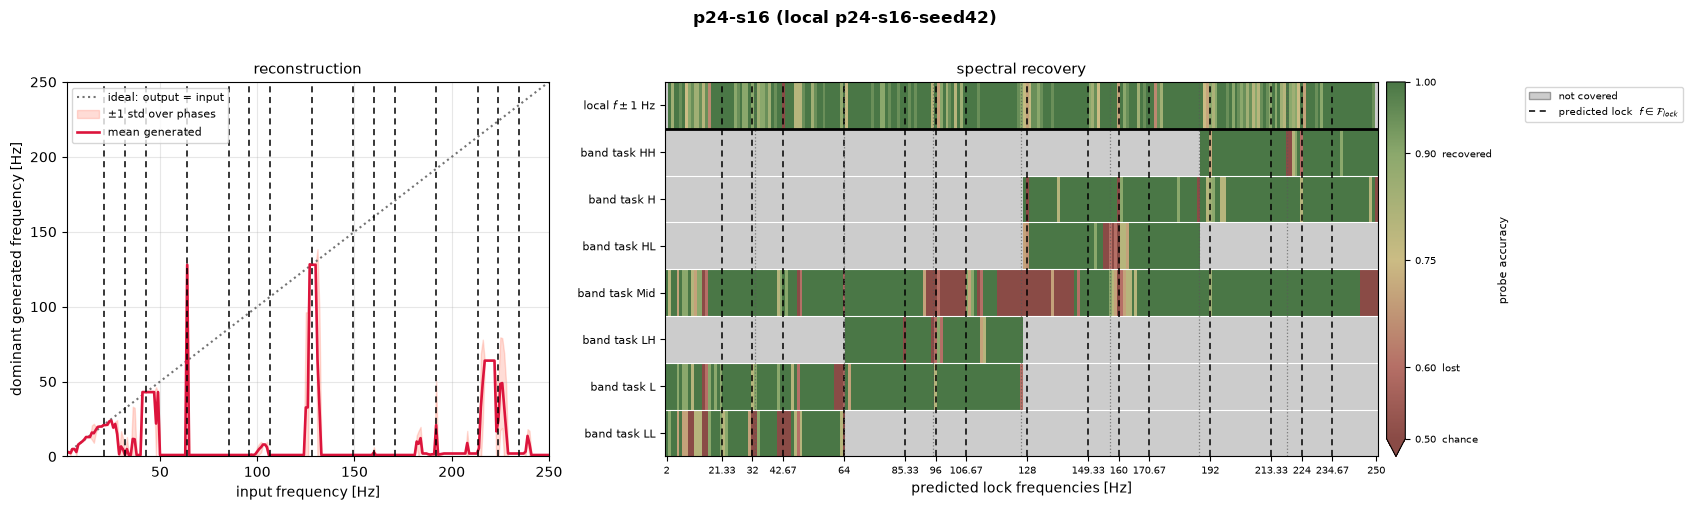

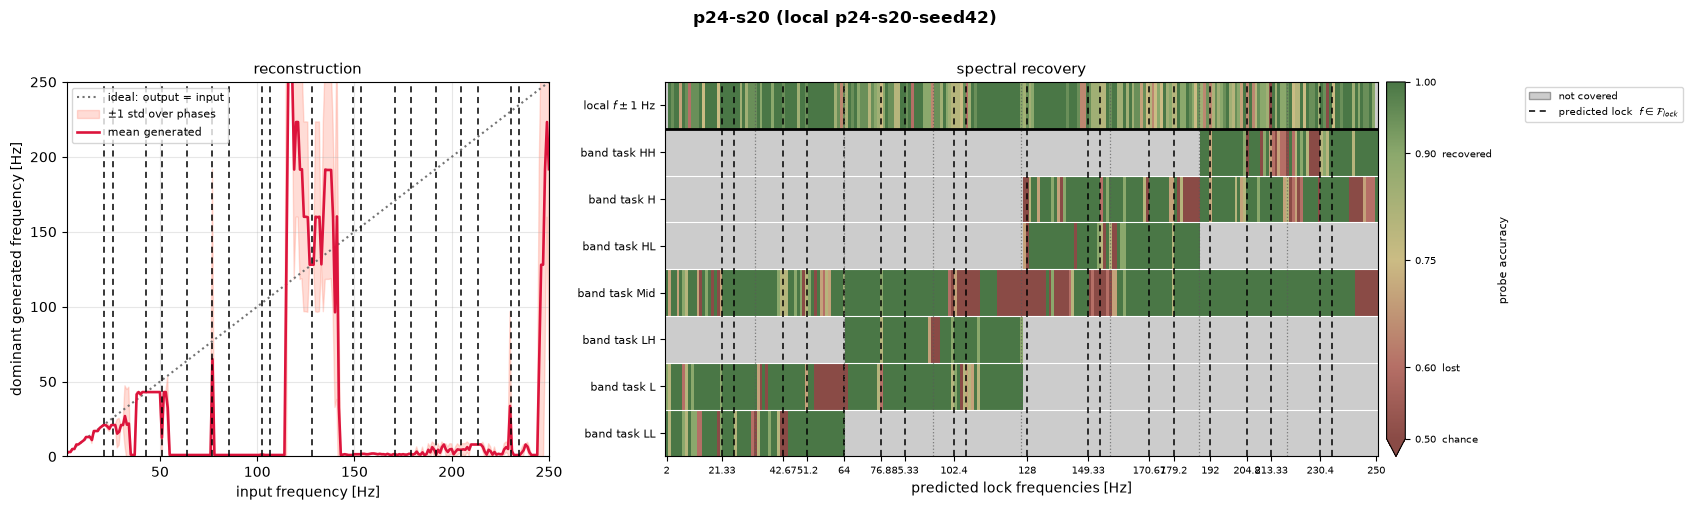

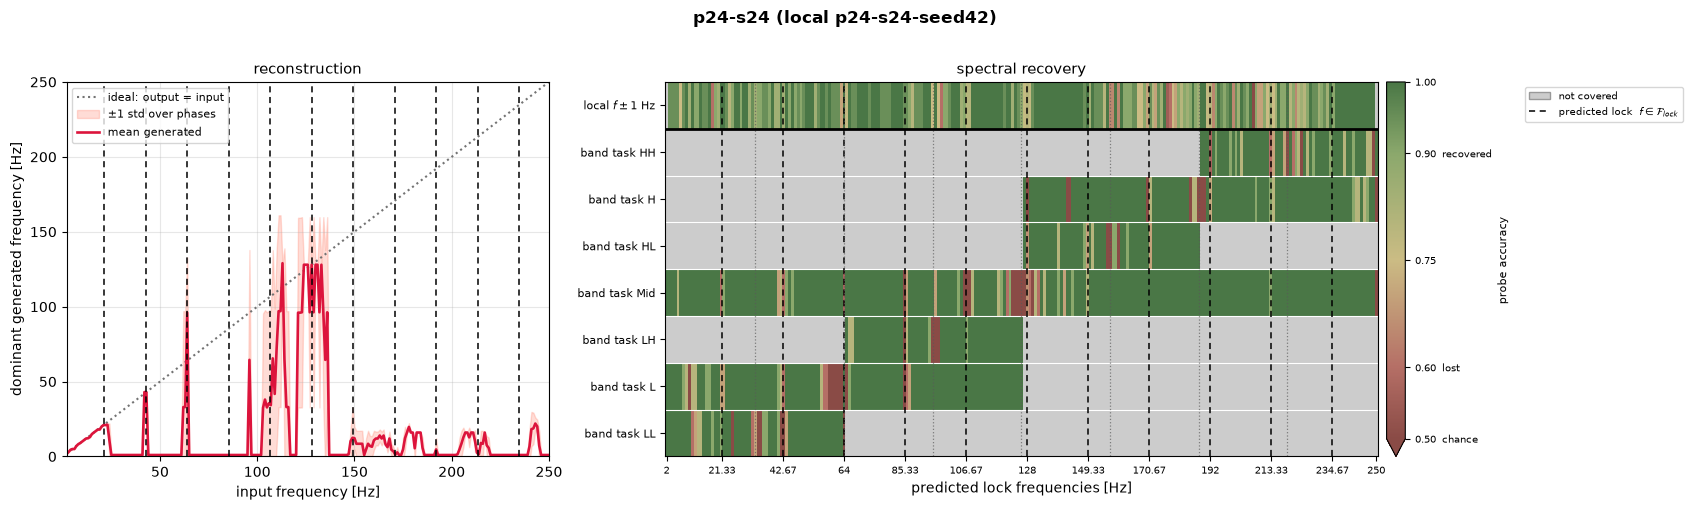

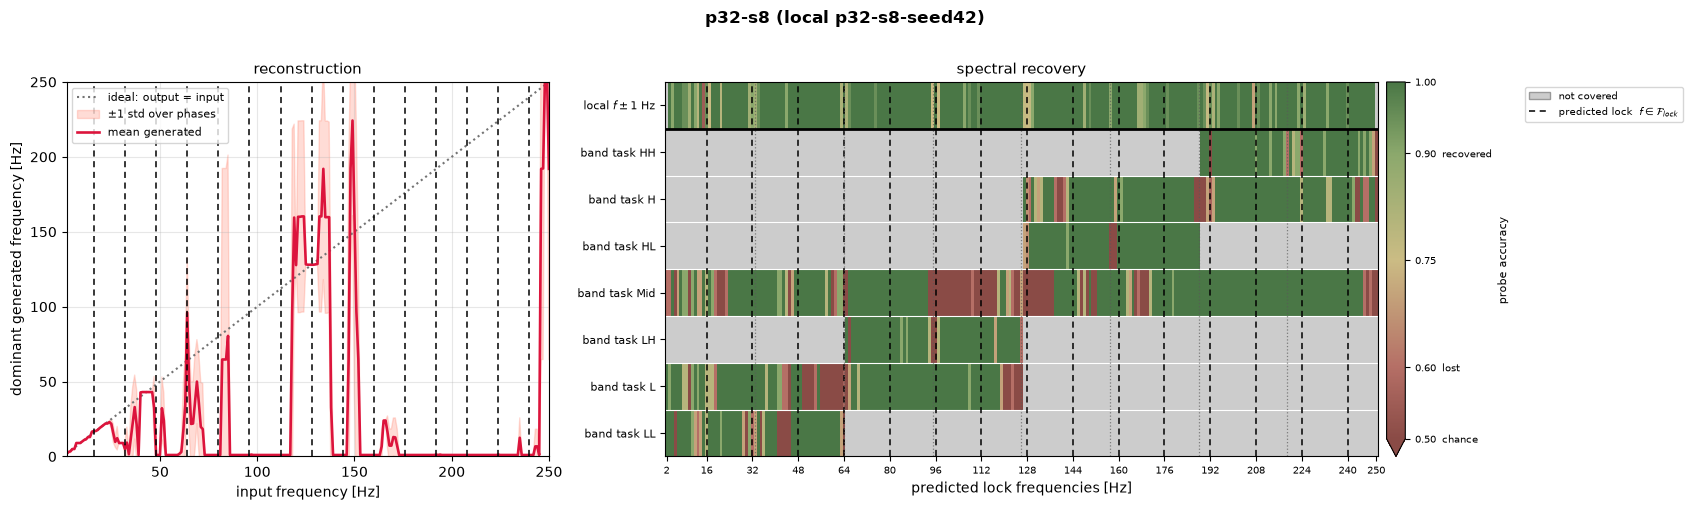

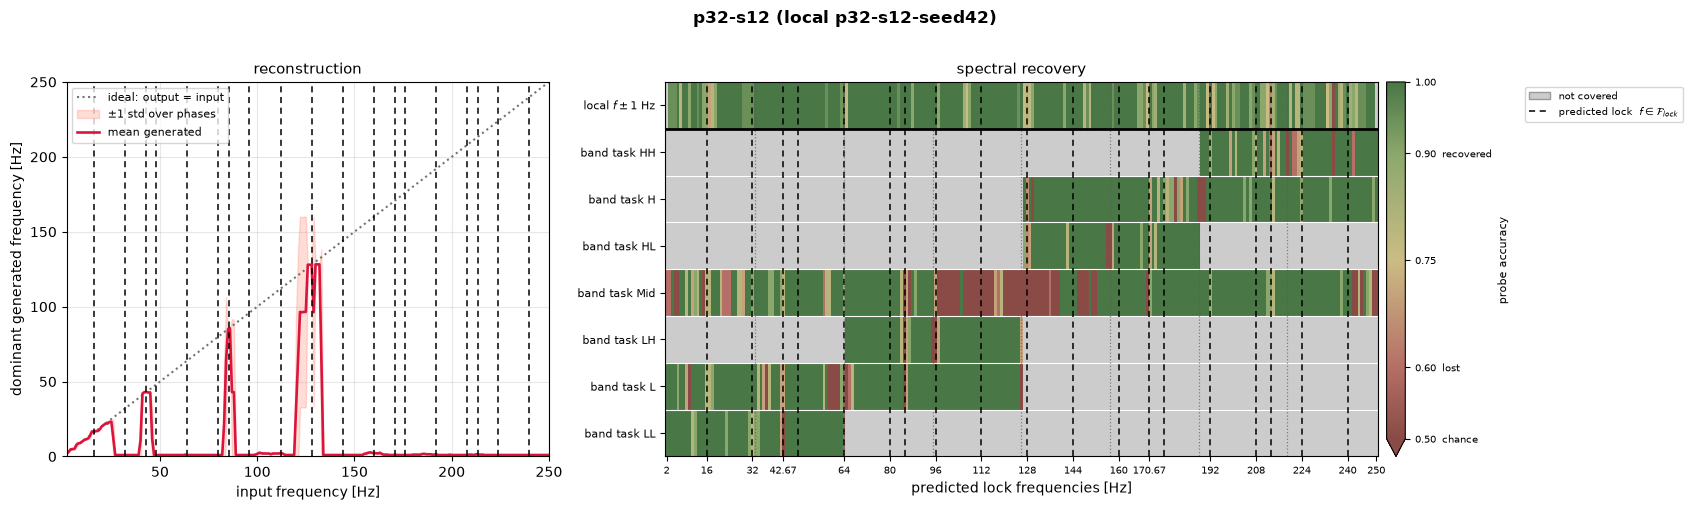

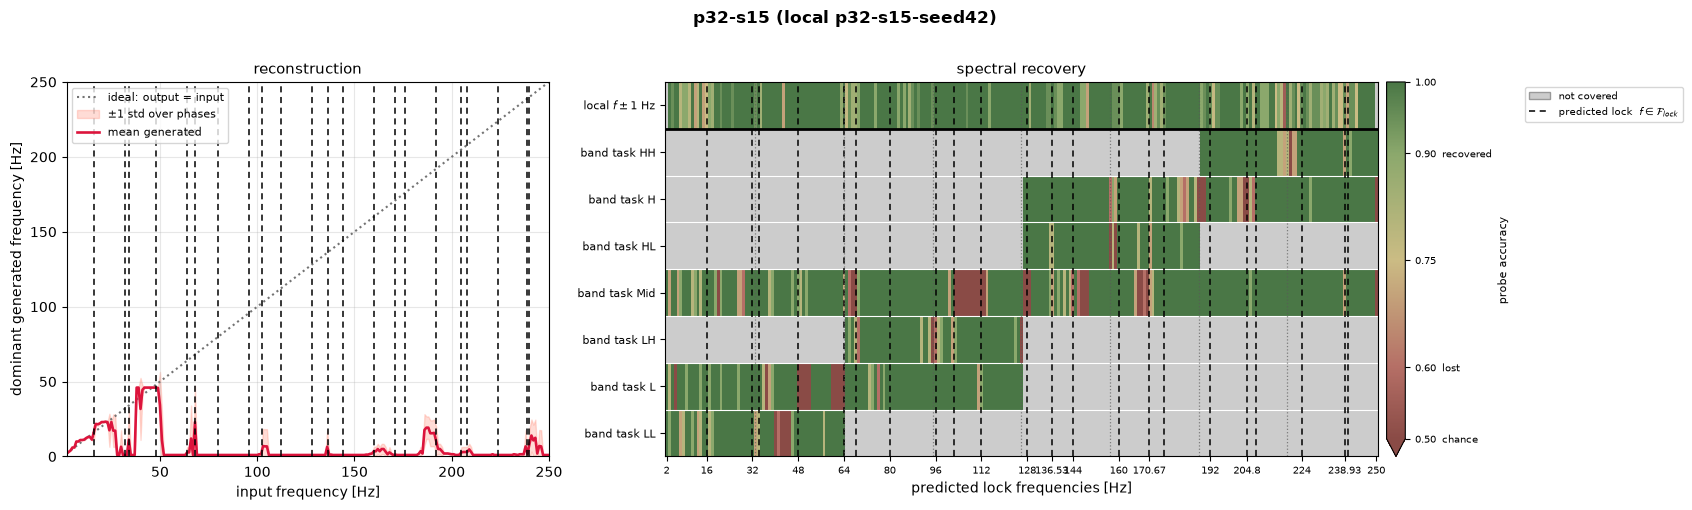

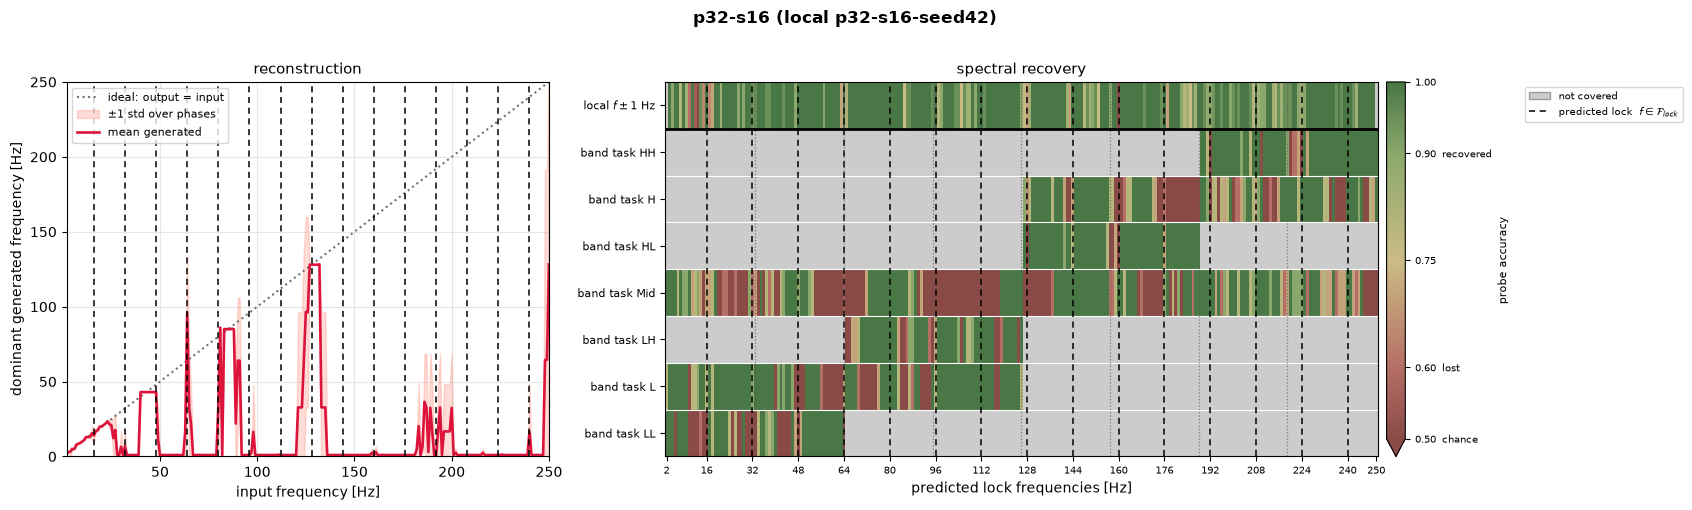

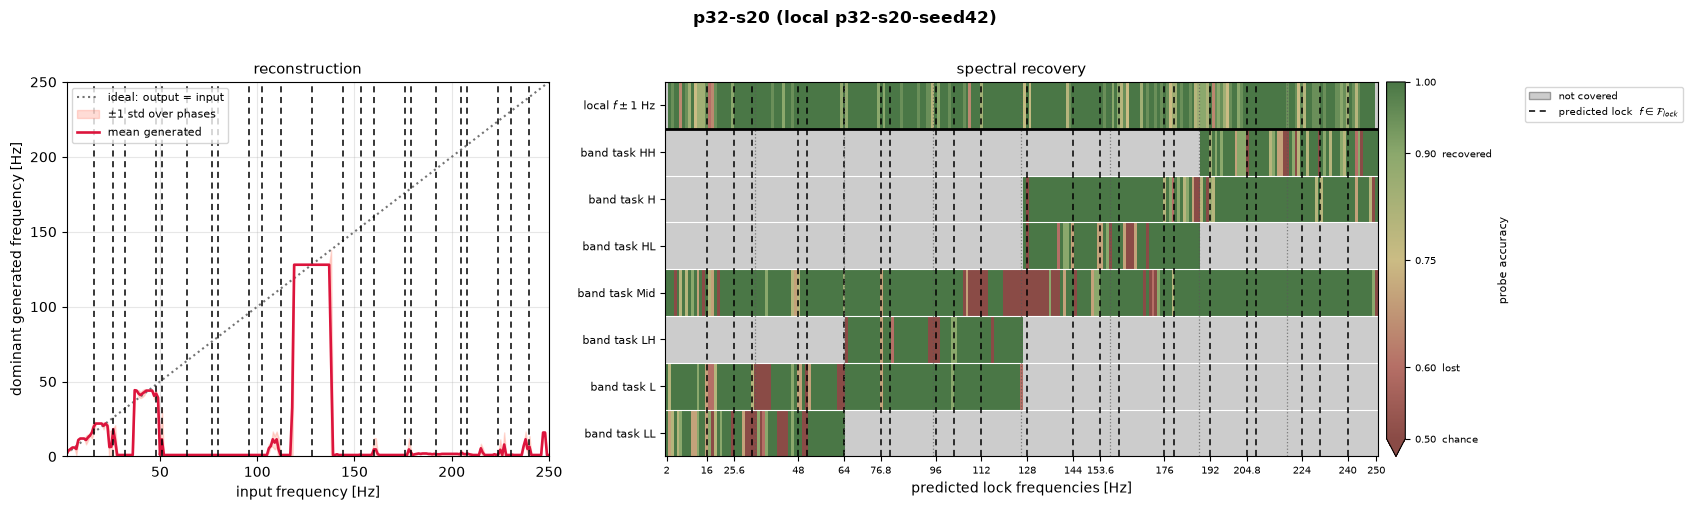

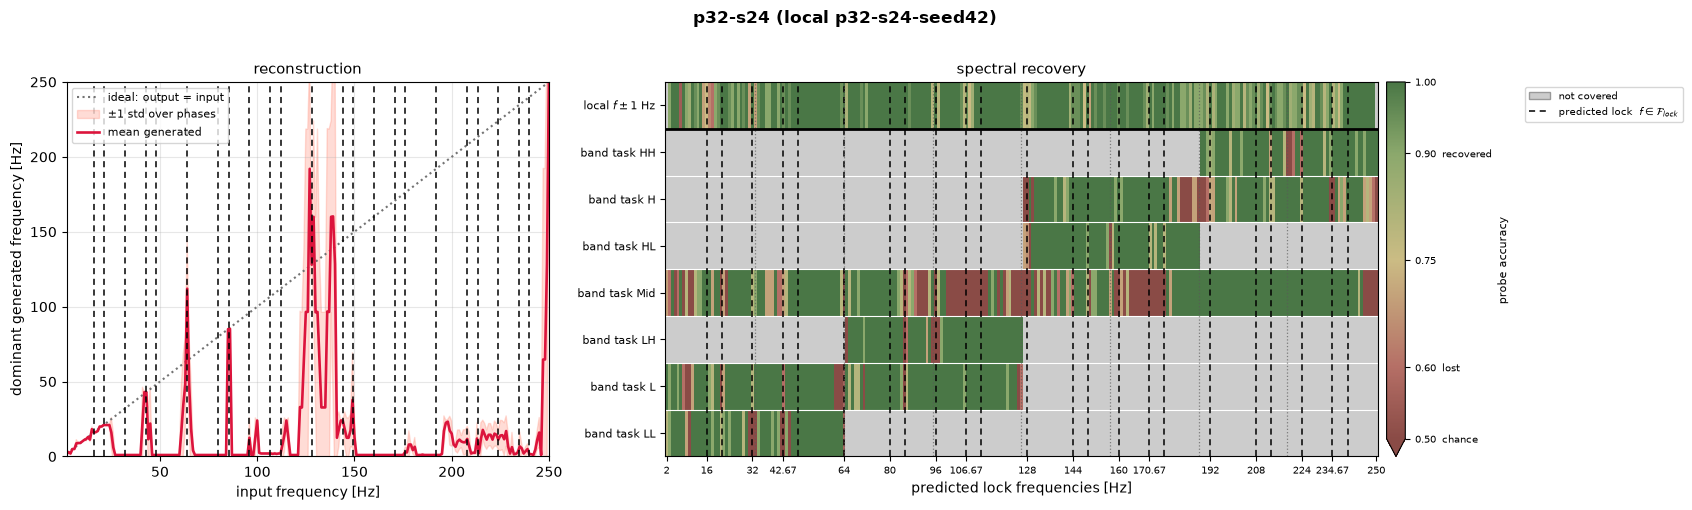

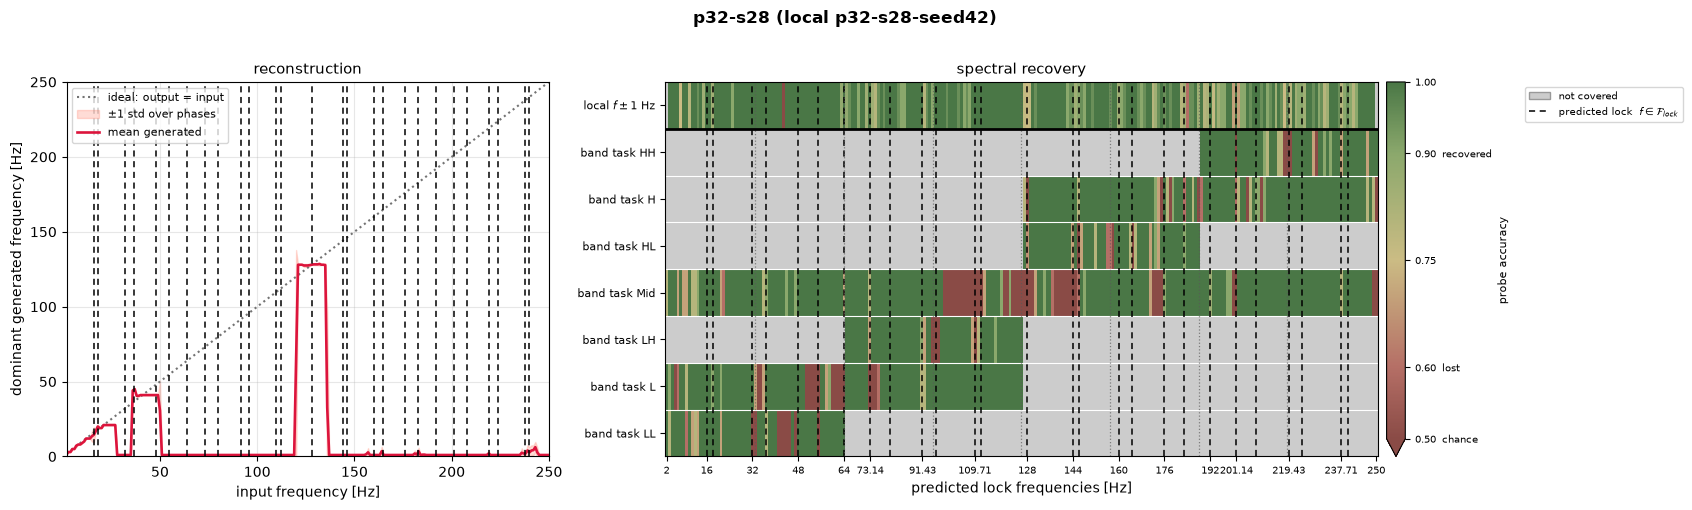

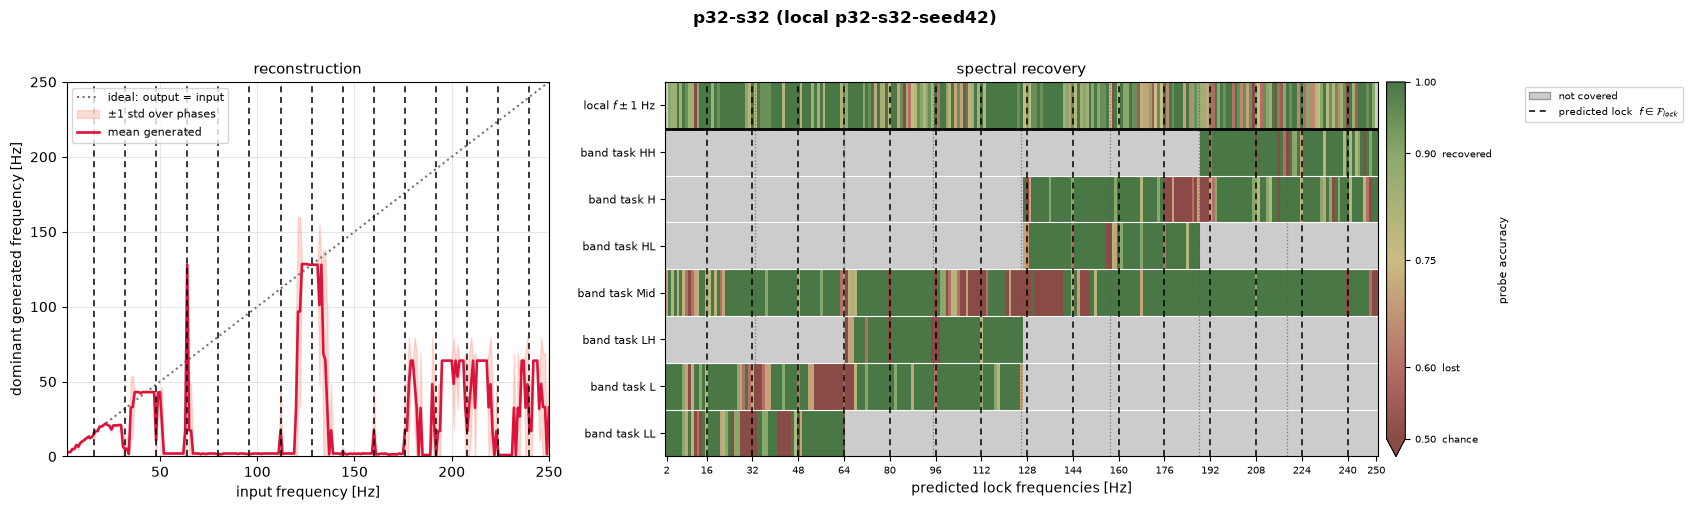

In [6]:
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap, Normalize

# --- the recovery colour scale ---------------------------------------------------------------
# Pagani et al. read spectral recovery as three states and the three colours below are that
# reading. What changes here is that the scale BETWEEN them is continuous: a probe at 0.72 is
# drawn between yellow and green instead of being rounded into a bin, so a band that degrades
# gradually reads as a gradient and not as a staircase, and two cells that fell in the same bin
# for very different reasons stop looking identical.
#
# The anchors keep the old thresholds meaningful rather than discarding them. 0.5 is chance on a
# two-class task and is the bottom of the scale; 0.6 and 0.9 were the boundaries of the old
# "lost" and "recovered" bins and still carry their old colours exactly, so a figure drawn with
# this scale can be read against one drawn with the discrete one. Below chance clips to the
# darkest red; a cell with no measurement is grey, which is a different statement from "worst".
ACC_MIN = 0.5
# Muted rather than saturated, as in the paper's own figure: at full saturation the map reads as
# alarm colours and the eye goes to the brightest cell instead of to the structure. Desaturated,
# the dark bands at the locked frequencies are still the first thing seen, which is the point.
ACC_STOPS = [(0.50, "#8a4b46"),      # at or below chance
             (0.60, "#b56f66"),      # the old "lost" red, dusty
             (0.75, "#cbbc84"),      # the old "partial" yellow, sand
             (0.90, "#8ba86c"),      # the old "recovered" boundary, sage
             (1.00, "#4a7746")]      # perfect
CMAP = LinearSegmentedColormap.from_list(
    "recovery", [((v - ACC_MIN) / (1.0 - ACC_MIN), c) for v, c in ACC_STOPS])
CMAP.set_bad("#cccccc")              # not covered: no task reaches this frequency
CMAP.set_under("#8a4b46")            # below chance
NORM = Normalize(vmin=ACC_MIN, vmax=1.0)
CBAR_TICKS  = [0.50, 0.60, 0.75, 0.90, 1.00]
CBAR_LABELS = ["0.50  chance", "0.60  lost", "0.75", "0.90  recovered", "1.00"]

def recovery_mesh(a):
    """Accuracy -> masked array, so a missing measurement draws grey and not as the worst value."""
    return np.ma.masked_invalid(np.asarray(a, dtype=float))

def add_recovery_colourbar(fig, mesh, ax, fraction=0.035):
    cb = fig.colorbar(mesh, ax=ax, pad=0.012, fraction=fraction, extend="min")
    cb.set_ticks(CBAR_TICKS); cb.set_ticklabels(CBAR_LABELS)
    cb.ax.tick_params(labelsize=7)
    cb.set_label("probe accuracy", fontsize=8)
    return cb

# Lock markers have to read on top of the whole scale, so they are drawn as high-contrast lines
# with a white halo rather than as thin coloured rules.
HALO = [pe.Stroke(linewidth=5.0, foreground="white"), pe.Normal()]
# One marker for the whole locked class F_lock, rather than one per family: the two coincide on
# every P=S geometry, and separating them added a distinction the figure does not need to make.
C_LOCK = "#000000"                            # black
DASH_LOCK = (0, (4, 3))                       # dashed, fine
LINE_OVER_TOP = 0.22          # the markers run past the top of the band, where nothing else is
LINE_OVER_BOT = 0.0           # and NOT past the bottom, where the tick labels are

def lock_frequencies(geometries):
    """Every predicted site of every geometry, so all panels share one set of ticks."""
    v = set()
    for (P, S) in geometries:
        v |= {round(f, 2) for f in pl.patch_nulls(P)}
        v |= {round(f, 2) for f in pl.stride_locks(S)}
    return sorted(v)

LOCK_TICKS = lock_frequencies(GEOMETRIES)

def band_edges(freqs, gap=6.0, min_sep=7.0):
    """Add the first and last swept frequency to a tick list, so every axis states its own range.

    Two thinnings, both about labels colliding rather than about the physics. A lock within `gap`
    of an edge is dropped in favour of the edge itself; and once the two grids are dense, as they
    are at the long strides, neighbouring locks print on top of one another, so a lock closer than
    `min_sep` to the last one kept is left unlabelled. Every lock is still drawn as a dashed line:
    what is thinned here is the tick text, not the marker.
    """
    lo, hi = float(FREQS[0]), float(FREQS[-1])
    keep = [f for f in sorted(freqs) if abs(f - lo) > gap and abs(f - hi) > gap]
    out, last = [], None
    for f in keep:
        if last is None or f - last >= min_sep:
            out.append(f); last = f
    return sorted({lo, hi} | set(out))

def own_locks(P, S):
    """The predicted sites of ONE geometry: what that panel's axis should be ticked with."""
    return sorted({round(f, 2) for f in pl.patch_nulls(P)} |
                  {round(f, 2) for f in pl.stride_locks(S)})

def label_lock_axis(ax, freqs, to_pos, rotation=0, fontsize=7):
    """Tick the frequency axis at given lock frequencies instead of round numbers."""
    ax.set_xticks([to_pos(f) for f in freqs])
    ax.set_xticklabels([f"{f:g}" for f in freqs], rotation=rotation, fontsize=fontsize)

# The colour scale is now carried by the colourbar, so the legend states only what the colourbar
# cannot: the grey of an unmeasured cell, and the lock markers.
LEGEND = [Patch(fc="#cccccc", ec="0.6", label="not covered"),
          Line2D([0], [0], color=C_LOCK, lw=1.1, ls=DASH_LOCK,
                 label="predicted lock  $f \\in \\mathcal{F}_{lock}$")]

def xpos(f):
    return np.interp(f, FREQS, np.arange(len(FREQS))) + 0.5

def display_order(results):
    """Panels read left-to-right by patch size, then stride."""
    return sorted(results, key=lambda t: (results[t]["P"], results[t]["S"]))

# --- every figure this notebook draws is written to OUT, one file per figure ------------------
SAVED = []

def save(fig, name, dpi=150):
    path = OUT / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    SAVED.append(name)
    return path

# --- the two panels, each drawable on its own axes so each can also be saved on its own --------
def draw_reconstruction(ax, r, legend=True):
    rc = r["recon"]
    ax.plot(pl.BAND, pl.BAND, ls=":", color="0.45", lw=1.5, label="ideal: output = input")
    ax.fill_between(rc["freq"], rc["mean"] - rc["std"].fillna(0), rc["mean"] + rc["std"].fillna(0),
                    color="tomato", alpha=.22, label="$\\pm$1 std over phases")
    ax.plot(rc["freq"], rc["mean"], color="crimson", lw=1.9, label="mean generated")
    for fk in pl.f_lock(r["P"], r["S"]):
        ax.axvline(fk, color=C_LOCK, lw=1.1, ls=DASH_LOCK, alpha=1.0)
    ax.set_xlabel("input frequency [Hz]"); ax.set_ylabel("dominant generated frequency [Hz]")
    ax.set_xlim(pl.BAND); ax.set_ylim(0, pl.BAND[1]); ax.grid(alpha=.3)
    if legend:
        ax.legend(loc="upper left", fontsize=8)

def draw_spectral(ax, r, fig, colourbar=True, legend=True, cb_fraction=0.035):
    acc, labels = r["acc"], r["row_labels"]
    mesh = ax.pcolormesh(np.arange(len(FREQS) + 1), np.arange(len(labels) + 1),
                         recovery_mesh(acc), cmap=CMAP, norm=NORM,
                         shading="flat", edgecolors="none", rasterized=True)
    for y in range(1, len(labels)):                    # thin separators instead of a cell grid,
        ax.axhline(y, color="white", lw=0.8)           # which a gradient cannot afford
    for fk in pl.f_lock(r["P"], r["S"]):
        ax.axvline(xpos(fk), color=C_LOCK, lw=1.1, ls=DASH_LOCK)
    for (_n, _lo, _hi, bnd) in pl.BAND_TASKS:
        ax.axvline(xpos(bnd), color="0.35", lw=.9, ls=":", alpha=.7)
    ax.axhline(len(labels) - 1, color="k", lw=2)       # the trustworthy row, separated
    ax.set_yticks(np.arange(len(labels)) + 0.5); ax.set_yticklabels(labels, fontsize=8)
    label_lock_axis(ax, band_edges(own_locks(r["P"], r["S"])), xpos)
    ax.set_xlabel("predicted lock frequencies [Hz]")
    if colourbar:
        add_recovery_colourbar(fig, mesh, ax, fraction=cb_fraction)
    if legend:
        ax.legend(handles=LEGEND, bbox_to_anchor=(1.20, 1), loc="upper left", fontsize=7.5)
    return mesh

for tag in display_order(RESULTS):
    r = RESULTS[tag]

    # --- the pair, side by side: what the model outputs next to what it still knows ------------
    fig, (a0, a1) = plt.subplots(1, 2, figsize=(17, 5),
                                 gridspec_kw={"width_ratios": [1, 1.55]})
    draw_reconstruction(a0, r); a0.set_title("reconstruction", fontsize=11)
    draw_spectral(a1, r, fig);  a1.set_title("spectral recovery", fontsize=11)
    fig.suptitle(r["label"], fontweight="bold", y=1.01)
    fig.tight_layout()
    save(fig, f"FIG_{tag}.png")
    plt.show()

    # --- and each panel again on its own, so either can be used as a standalone figure ---------
    f1, ax = plt.subplots(figsize=(7.0, 5.0))
    draw_reconstruction(ax, r)
    ax.set_title(f"{r['label']} — reconstruction", fontsize=11)
    f1.tight_layout(); save(f1, f"FIG_{tag}_reconstruction.png"); plt.close(f1)

    f2, ax = plt.subplots(figsize=(11.5, 4.8))
    draw_spectral(ax, r, f2, cb_fraction=0.030)
    ax.set_title(f"{r['label']} — spectral recovery", fontsize=11)
    f2.tight_layout(); save(f2, f"FIG_{tag}_spectral_recovery.png"); plt.close(f2)


## 3, All geometries side by side

The per-geometry figures above answer *what does this model do*. These two answer the question the
sweep exists for: **does the behaviour move when the tokenisation geometry changes?** The predicted
sites are drawn on every panel, so a dip that follows its own geometry's markers from panel to panel
is the phenomenon, and one that stays put across geometries is not.

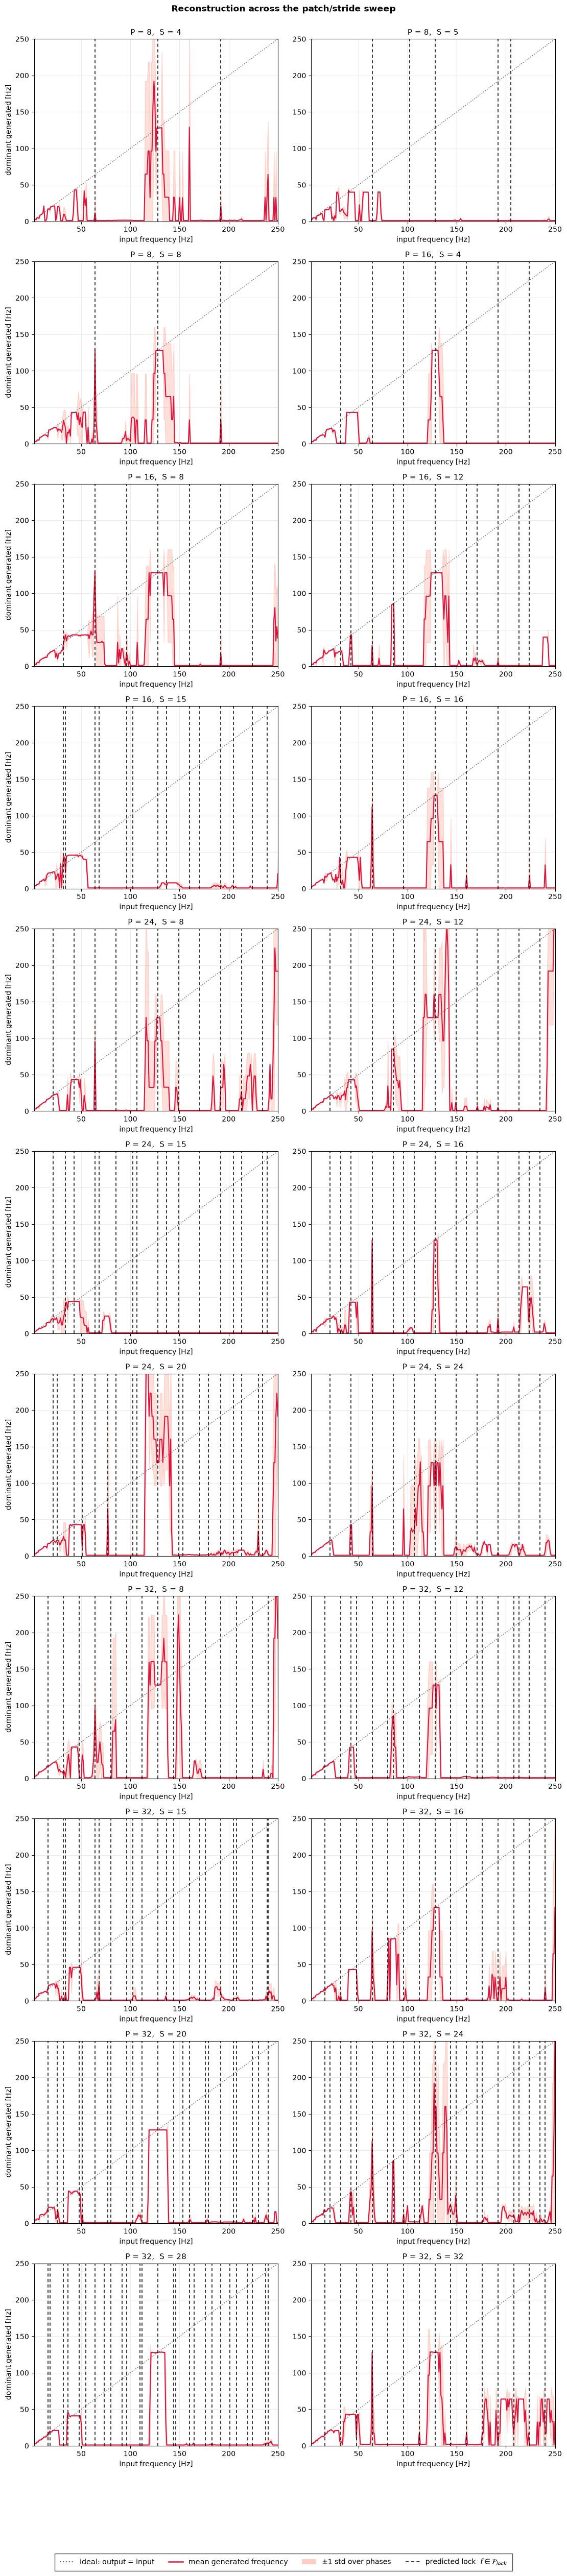

In [7]:
import math
tags_r = display_order(RESULTS)
ncols = 2
nrows = math.ceil(len(tags_r) / ncols)
fig, axgrid = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 4.4 * nrows),
                           sharex=True, sharey=True, squeeze=False)
flat = axgrid.ravel()
for ax, t in zip(flat, tags_r):
    r = RESULTS[t]; rc = r["recon"]
    ax.plot(pl.BAND, pl.BAND, ls=":", color="0.45", lw=1.2)
    ax.fill_between(rc["freq"], rc["mean"] - rc["std"].fillna(0), rc["mean"] + rc["std"].fillna(0),
                    color="tomato", alpha=.20)
    ax.plot(rc["freq"], rc["mean"], color="crimson", lw=1.5)
    for fk in pl.f_lock(r["P"], r["S"]):
        ax.axvline(fk, color=C_LOCK, lw=1.1, ls=DASH_LOCK, alpha=1.0)
    ax.set_title(f"P = {r['P']},  S = {r['S']}", fontsize=11)
    ax.grid(alpha=.25)
    ax.tick_params(labelbottom=True, labelleft=True)
    ax.set_xlabel("input frequency [Hz]")
# With an odd number of geometries the grid leaves one slot empty: put the legend there rather
# than stealing height from the panels.
RECON_LEGEND = [
    Line2D([0], [0], ls=":", color="0.45", lw=1.6, label="ideal: output = input"),
    Line2D([0], [0], color="crimson", lw=1.8, label="mean generated frequency"),
    Patch(fc="tomato", alpha=.30, label="$\\pm$1 std over phases"),
    Line2D([0], [0], color=C_LOCK, lw=1.1, ls=DASH_LOCK,
           label="predicted lock  $f \\in \\mathcal{F}_{lock}$"),
]
spare = list(flat[len(tags_r):])
for ax in spare:
    ax.axis("off")
if spare:
    spare[0].legend(handles=RECON_LEGEND, loc="center", frameon=True, fancybox=False,
                    edgecolor="0.3", framealpha=1, fontsize=11,
                    handlelength=2.6, labelspacing=1.1, borderpad=1.0)
else:
    fig.legend(handles=RECON_LEGEND, loc="lower center", bbox_to_anchor=(0.5, -0.04),
               ncol=5, frameon=True, fancybox=False, edgecolor="0.3", framealpha=1,
               fontsize=10, borderpad=0.7)
for row in axgrid:
    row[0].set_ylabel("dominant generated [Hz]")
flat[0].set_xlim(pl.BAND); flat[0].set_ylim(0, pl.BAND[1])
fig.suptitle("Reconstruction across the patch/stride sweep", fontweight="bold", y=1.0)
fig.tight_layout()
save(fig, "FIG_ALL_reconstruction.png")
plt.show()

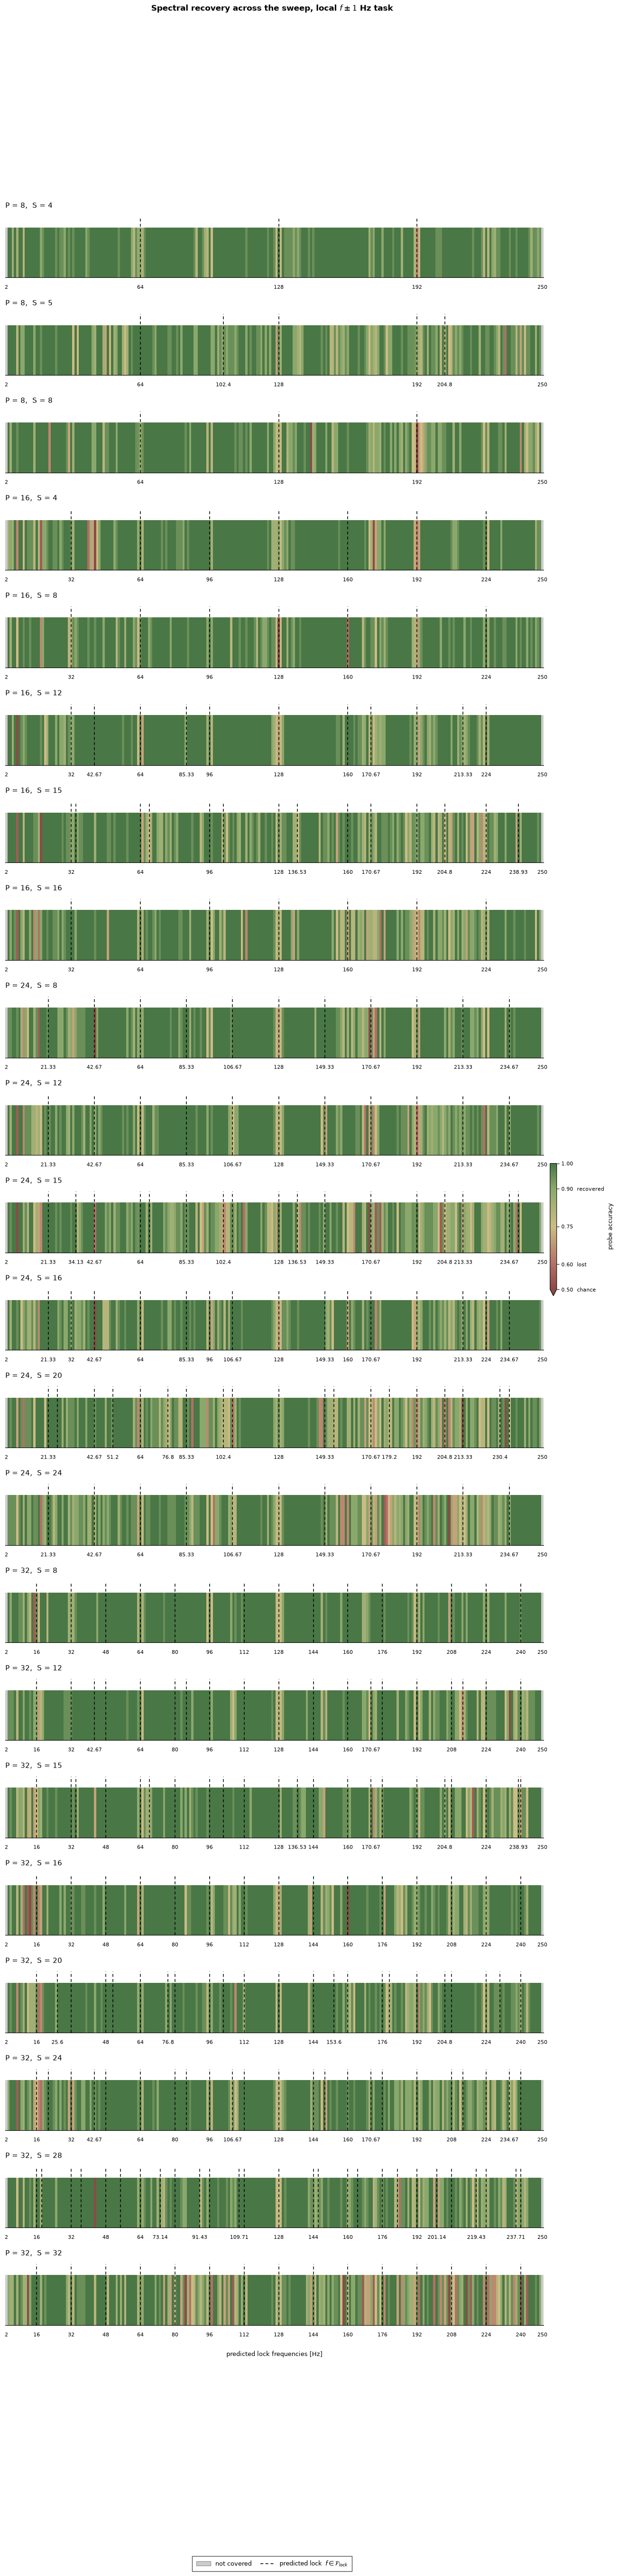

,model,P,S,spectral_RMSE_Hz,pct_on_diagonal,pct_recovered,pct_lost
0,p8-s4,8,4,137.3,9.6,90.8,0.0
1,p8-s5,8,5,143.3,6.8,83.9,0.0
2,p8-s8,8,8,137.7,12.9,85.1,0.8
3,p16-s4,16,4,140.9,12.0,87.6,1.2
4,p16-s8,16,8,133.8,13.3,90.0,0.4
5,p16-s12,16,12,136.2,12.4,88.4,0.4
6,p16-s15,16,15,142.6,7.6,79.5,0.8
7,p16-s16,16,16,139.8,11.6,79.5,0.4
8,p24-s8,24,8,129.5,13.3,85.9,1.2
9,p24-s12,24,12,129.2,13.3,84.7,0.4



68 figures written to C:\Users\feder\Desktop\patchAliasing\chronos\bayesian\_run\full\pagani
    FIG_p8-s4.png
    FIG_p8-s4_reconstruction.png
    FIG_p8-s4_spectral_recovery.png
    FIG_p8-s5.png
    FIG_p8-s5_reconstruction.png
    FIG_p8-s5_spectral_recovery.png
    FIG_p8-s8.png
    FIG_p8-s8_reconstruction.png
    FIG_p8-s8_spectral_recovery.png
    FIG_p16-s4.png
    FIG_p16-s4_reconstruction.png
    FIG_p16-s4_spectral_recovery.png
    FIG_p16-s8.png
    FIG_p16-s8_reconstruction.png
    FIG_p16-s8_spectral_recovery.png
    FIG_p16-s12.png
    FIG_p16-s12_reconstruction.png
    FIG_p16-s12_spectral_recovery.png
    FIG_p16-s15.png
    FIG_p16-s15_reconstruction.png
    FIG_p16-s15_spectral_recovery.png
    FIG_p16-s16.png
    FIG_p16-s16_reconstruction.png
    FIG_p16-s16_spectral_recovery.png
    FIG_p24-s8.png
    FIG_p24-s8_reconstruction.png
    FIG_p24-s8_spectral_recovery.png
    FIG_p24-s12.png
    FIG_p24-s12_reconstruction.png
    FIG_p24-s12_spectral_recovery.png
   

In [8]:
# One panel per geometry, sharing a single legend and colour scale: each carries its own
# frequency axis, so a band can be read without tracing across to another panel's ticks.
tags = display_order(RESULTS)
fig, axes = plt.subplots(len(tags), 1, figsize=(15, 2.45 * len(tags) + 1.4), squeeze=False)
axes = axes[:, 0]
fig.subplots_adjust(hspace=0.95, top=0.90, bottom=0.10)

mesh = None
for ax, t in zip(axes, tags):
    r = RESULTS[t]
    mesh = ax.pcolormesh(np.arange(len(FREQS) + 1), np.array([0, 1]),
                         recovery_mesh(r["acc"][-1])[None, :],
                         cmap=CMAP, norm=NORM, shading="flat", edgecolors="none",
                         rasterized=True, zorder=2)
    for fk in pl.f_lock(r["P"], r["S"]):
        ax.plot([xpos(fk)] * 2, [-LINE_OVER_BOT, 1 + LINE_OVER_TOP], color=C_LOCK, lw=1.1,
                ls=DASH_LOCK, zorder=4, clip_on=False)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_title(f"P = {r['P']},  S = {r['S']}", fontsize=11, pad=30, loc="left")
    label_lock_axis(ax, band_edges(own_locks(r["P"], r["S"])), xpos, fontsize=8)
    ax.tick_params(axis="x", length=0, pad=11)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)

axes[-1].set_xlabel("predicted lock frequencies [Hz]", fontsize=9.5, labelpad=20)
cb = fig.colorbar(mesh, ax=axes.tolist(), pad=0.012, fraction=0.012, extend="min")
cb.set_ticks(CBAR_TICKS); cb.set_ticklabels(CBAR_LABELS)
cb.ax.tick_params(labelsize=8); cb.set_label("probe accuracy", fontsize=9)
fig.suptitle("Spectral recovery across the sweep, local $f\pm1$ Hz task",
             fontweight="bold", y=0.985)
fig.legend(handles=LEGEND, loc="lower center", bbox_to_anchor=(0.5, 0.005),
           ncol=6, frameon=True, fancybox=False, edgecolor="0.3", framealpha=1,
           fontsize=9, handlelength=2.4, columnspacing=1.5, borderpad=0.7)
save(fig, "FIG_ALL_spectral_recovery.png")
plt.show()

summary = pd.DataFrame([
    dict(model=t,
         P=RESULTS[t]["P"], S=RESULTS[t]["S"],
         spectral_RMSE_Hz=round(float(np.sqrt(np.mean(
             (RESULTS[t]["recon"]["mean"] - RESULTS[t]["recon"]["freq"]) ** 2))), 1),
         pct_on_diagonal=round(float(np.mean(
             np.abs(RESULTS[t]["recon"]["mean"] - RESULTS[t]["recon"]["freq"]) <= 2.0)) * 100, 1),
         pct_recovered=round(float(np.nanmean(RESULTS[t]["acc"][-1] >= 0.9)) * 100, 1),
         pct_lost=round(float(np.nanmean(RESULTS[t]["acc"][-1] < 0.6)) * 100, 1))
    for t in display_order(RESULTS)])
summary.to_parquet(OUT / "reconstruction_summary.parquet", index=False)
display(summary)

# --- what was written -------------------------------------------------------------------------
print(f"\n{len(SAVED)} figures written to {OUT}")
for name in SAVED:
    print("   ", name)


## How to read the two together

The reconstruction panel says what the model *outputs*; the recovery panel says what it still
*knows*. They can disagree, and each combination means something different:

* **on the diagonal and green**, the frequency is represented and rebuilt;
* **off the diagonal but green**, the information survives in the representation and is lost at the
  projection, which points at the head rather than at the tokenisation;
* **red**, the frequency is not recoverable from the representation at all, which is the stronger
  claim and the one structural aliasing predicts at the locked frequencies.

The colour scale is continuous between those readings, so it also carries what a three-state map
cannot: how *far* a column has moved. A column at $0.72$ sits between yellow and green and is a
partial loss; one at $0.52$ is at the dark end and is indistinguishable from chance. **Grey is not
the bottom of the scale**: it means no task covers that frequency, which is a statement about the
design and not about the model.

The dashed markers are the frequencies the geometry predicts as locked, $\mathcal{F}_{lock}$: the
union of the patch nulls $k f_s/P$ and the stride locks $c f_s/S$. Where the two grids are dense the
tick *labels* are thinned so they do not print on top of one another, but every predicted lock is
still drawn. On any $P=S$ geometry the two families coincide, and only the $S \nmid P$
configurations separate them.
